# Simple 2D inversion test

The following is a toy example to illustrate how to use `pyesmda`. It exposes the main useful features. The forward is simple static smoohting (non linear but with no time dependance) and is used both to produce a reference field from which observations will be sampled and the inversion.

- Import the required modules

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import covmats
import pyesmda
from pyesmda._utils import NDArrayFloat
import logging
import nested_grid_plotter as ngp

- Apply nice parameters for the plots

In [24]:
ngp.apply_nice_default_rc_params()

- Create some logging instances to illustrate how to use them in a complex workflow

In [25]:
# Create loggers
main_logger = logging.getLogger("main")
main_logger.setLevel(logging.INFO)
esmda_logger = logging.getLogger("ESMDA")
esmda_logger.setLevel(logging.INFO)
main_logger.info("This is the main logger")
esmda_logger.info("This is the ESMDA logger")

INFO:main:This is the main logger
INFO:ESMDA:This is the ESMDA logger


Let's use an example provided by `covmats`. Here, the prior covariance matrix, $\mathbf{C}_{\mathrm{prior}}$ is represented as a sparse factorization of its inverse $\mathbf{C}_{\mathrm{prior}}^{-1}$ with $\mathbf{LDL}^{\mathrm{T}} = \mathbf{PC}_{\mathrm{prior}}^{-1}\mathbf{P}^{\mathrm{T}}$. This is wrapped in the `covmats.CovViaSparsePrecisionCholesky` instance we create:

In [26]:
cov_prior = covmats.CovViaSparsePrecisionCholesky(
    covmats.load_precision_example_4225x_SCF()
)
cov_prior

<4225x4225 CovViaSparsePrecisionCholesky with dtype=float64>

The covariance matrix has shape (4225, 4225) , let's define a square domain (65, 65) and perform a non conditional simulation using our prior. We set a mean @ 50 and display it:

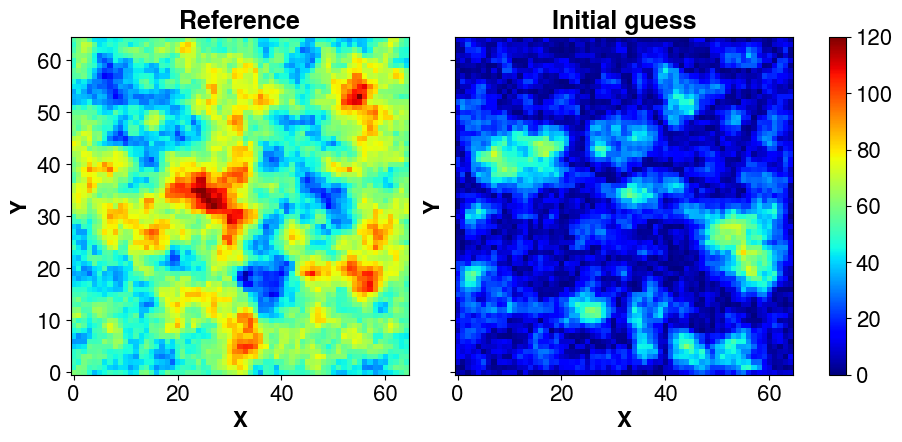

In [27]:
# Domain dimensions
nx = ny = int(np.sqrt(cov_prior.shape[0]))

# Non conditonal simulation -> change the random states (seeds) to obtain different fields
simu_ = cov_prior.sample_mvnormal(shape=(1,), random_state=2026).reshape(ny, nx).T
mean = 50.0
# Reference field
s_ref = np.abs(simu_ + mean)
# Initial guess
s_init = np.abs(
    cov_prior.sample_mvnormal(shape=(1,), random_state=15653).reshape(ny, nx).T
)

plotter = ngp.Plotter(
    fig=plt.figure(figsize=(9, 4.3)),
    builder=ngp.SubplotsMosaicBuilder([["ax11", "ax12"]], sharex=True, sharey=True),
)
ngp.multi_imshow(
    plotter.axes,
    plotter.fig,
    data={"Reference": s_ref, "Initial guess": s_init},
    xlabel="X",
    ylabel="Y",
    imshow_kwargs=dict(
        cmap=plt.get_cmap("jet"),
        aspect="equal",
        vmin=0.0,
        vmax=120,
    ),
)

The forward is simple static smoohting (non linear but with no time dependance) and is used both to produce a reference field from which observations will be sampled and the inversion. Here, `forward_multiple` is just the generalization to an ensemble of vectors, i.e., in ESMDA, forward calls for an iteration can be performed in parallel. But it is the responsibility of the user to decide and implement the sequential forward computation (a simple for loop as here) or the parallelized computation (with mpi, multiprocessing, joblib or whatever tool that suits best).

In [28]:
# Data transform operator
def transform_model(x: NDArrayFloat) -> NDArrayFloat:
    """Transform the input space into the output space."""
    return sp.ndimage.gaussian_filter(4.0 * x**2, sigma=2.0)


# Sampling operator
def sample_d(d: NDArrayFloat, sampling_fraction: float = 0.05) -> NDArrayFloat:
    """
    Sample within a vector.

    Parameters
    ----------
    d : NDArrayFloat
        Values to sample.
    sampling_fraction : float, optional
        Fraction of the values to sample, by default 0.05.
    """
    return d.ravel("F")[:: int(d.size / (sampling_fraction * 1000))]


def forward(x: NDArrayFloat) -> NDArrayFloat:
    """
    Forward model (data transform + sampling in the output space).

    Parameters
    ----------
    x : NDArrayFloat
        Input parameters vector with size (N_s).

    Returns
    -------
    NDArrayFloat
    """
    return sample_d(transform_model(x))


def forward_multiple(X: NDArrayFloat, *args, **kargs) -> NDArrayFloat:
    """
    Return the results of the forward for an ensemble of input vectors.

    Parameters
    ----------
    X : _type_
        Input vectors as a matrix with size (N_s, N_e), N_s being the number of
        parameter values per vector and N_e the number of vectors, aka the ensemble
        size.

    Returns
    -------
    NDArrayFloat
        _description_
    """
    res = []
    _X = np.atleast_2d(X.T)
    for i in range(_X.shape[0]):
        res.append(forward(_X[i, :].reshape(nx, ny, order="F")))
    return np.vstack(res).T


# The input vector much match a flatten version of the field (Here, 2D -> 1D).
obs = forward_multiple(s_ref.ravel("F"))[:, 0]

# Some test to check that all works as expected
s_ens = np.vstack([s_ref.ravel("F"), s_init.ravel("F")]).T
assert s_ens.shape == (nx * ny, 2)
d_pred = forward_multiple(s_ens)
assert d_pred.shape == (obs.size, 2)
np.testing.assert_almost_equal(d_pred[:, 0], obs)

Define the covariance matrix of observation errors (cov_obs). To illustrate a complex case, the matrix is assumed non diagonal. 

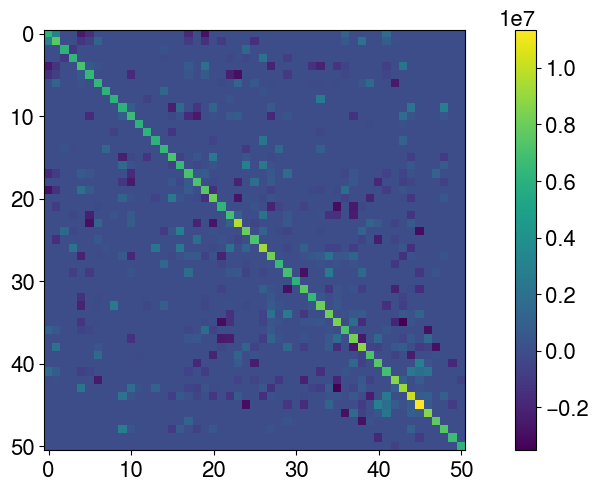

In [29]:
n = np.size(obs)
amplitude = np.max(obs) - np.min(obs)

# CASE 1: diagonal covariance matrix (this is the simplest case)
# 10% error on the observations
# cov_obs = covmats.CovViaDiagonal(
#     np.ones(n) * amplitude ** 2
# )

# CASE 2: non diagonal through Cholesky
L = np.zeros((n, n), dtype=np.float64)
# Add some random non-zero covariances
for i in range(n):
    for j in range(i + 1, n):
        if np.random.rand() < 0.1:  # 10% chance of non-zero covariance
            cov = np.random.uniform(-0.05, 0.05) * amplitude
            L[i, j] = cov
            L[j, i] = cov  # symmetry
# Add non zero diagonal
L.flat[:: n + 1] = amplitude * 0.1
# Make it lower triangular and define the covariance as a cholesky factorization
cov_obs = covmats.CovViaCholesky(np.tril(L))

# Show the dense matrix
plt.imshow(cov_obs.todense())
plt.colorbar()

Perturb the observations to avoid the inverse crime (using the same forward to generate the synthetic data and perform the inversion makes the problem well posed and simple to solve. Adding noise mitigates it a bit).

(787.3191490867721, 35303.22862408591)

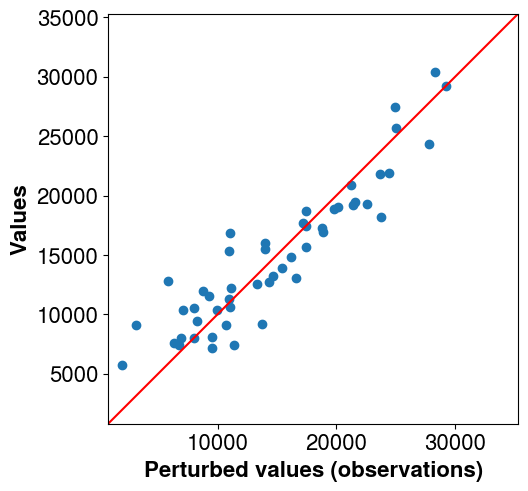

In [30]:
obs_perturb = (
    obs + cov_obs.sample_mvnormal([1], random_state=np.random.default_rng(2151))[0]
)
# Plot the non perturbed observations vs perturbed one
# The perturbed ones will be used for the inversion
pl = ngp.Plotter()
lims = (np.min(obs), np.max(obs))
diff = lims[1] - lims[0]
lims = (lims[0] - 0.2 * diff, lims[1] + 0.2 * diff)
pl.axes[0].plot(lims, lims, color="r")
pl.axes[0].scatter(obs_perturb, obs)
pl.axes[0].set_xlabel("Perturbed values (observations)")
pl.axes[0].set_ylabel("Values")
pl.axes[0].set_aspect("equal")
pl.axes[0].set_xlim(lims)
pl.axes[0].set_ylim(lims)

The next step is to "factorize" the parameters covariance matrix using an ensemble. For this, we rely on `covmats`. The number of members is set to 200.

In [31]:
ens_mat = covmats.CovViaEnsemble(cov_prior.sample_mvnormal((200,), random_state=2026))
assert ens_mat.n_pts == 4225

- Create the ESMDA instance

In [32]:
solver = pyesmda.ESMDA(
    obs=obs_perturb,
    m_init=np.abs(ens_mat.ensemble.T + 25.0),
    cov_obs=cov_obs,
    forward_model=forward_multiple,
    n_assimilations=6,
    random_state=2026,
    logger=esmda_logger,
    inversion_type=pyesmda.ESMDAInversionType.WOODBURY,
)
# Sanity checks just for the tests
assert solver.m_dim == 4225
assert solver.d_dim == obs.size

Run the inversion process

In [33]:
solver.solve()

INFO:ESMDA:Assimilation # 1
INFO:ESMDA:Assimilation # 2
INFO:ESMDA:Assimilation # 3
INFO:ESMDA:Assimilation # 4
INFO:ESMDA:Assimilation # 5
INFO:ESMDA:Assimilation # 6
INFO:ESMDA:Forecast for the final ensemble


The solver produces the a posterori ensemble which we can compute the mean => Plot the inverted field versus the reference one (in real world applications, the refrence is not know).

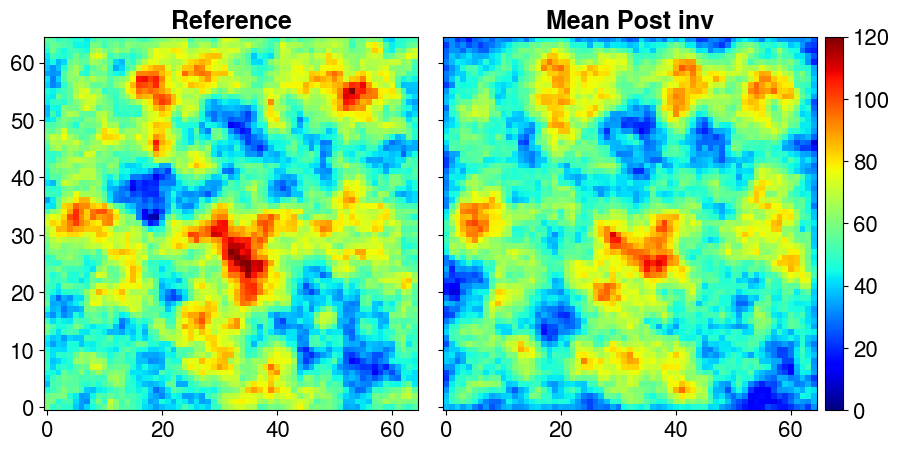

In [34]:
plotter = ngp.Plotter(
    plt.figure(figsize=(9.0, 4.4), constrained_layout=True),
    builder=ngp.SubplotsMosaicBuilder([["ref", "inv"]]),
)

ngp.multi_imshow(
    plotter.axes,
    data={
        "Reference": s_ref.T,
        "Mean Post inv": solver.m_prior.mean(-1).reshape(nx, ny, order="F").T,
    },
    fig=plotter.fig,
    imshow_kwargs=dict(
        origin="lower",
        cmap=plt.get_cmap("jet"),
        aspect="equal",
        vmin=0.0,
        vmax=120,
    ),
    cbar_kwargs=dict(pad=0.01),
)

This posterior ensemble also allows obtaining a low-rank approximation of the posterior covariance matrix. One can then extract the estimation variance. It is also possible to convert this low-rank matrix into another factorization, such as for example Eigen: in the present case, we construct the Eigen matrix with 50 and then with 100 principal components to compare the effects. We also construct the dense matrix (which is not possible for large-scale problems) for comparison.

In [35]:
post_cov_ens = covmats.CovViaEnsemble(solver.m_prior.T)
post_cov_dense = post_cov_ens.todense()
post_cov_50_pc = covmats.eigen_factorize_cov_mat(post_cov_ens, n_pc=50)
post_cov_100_pc = covmats.eigen_factorize_cov_mat(post_cov_ens, n_pc=100)

The higher the number of realizations or PC, the better the approximation of the posterior variance


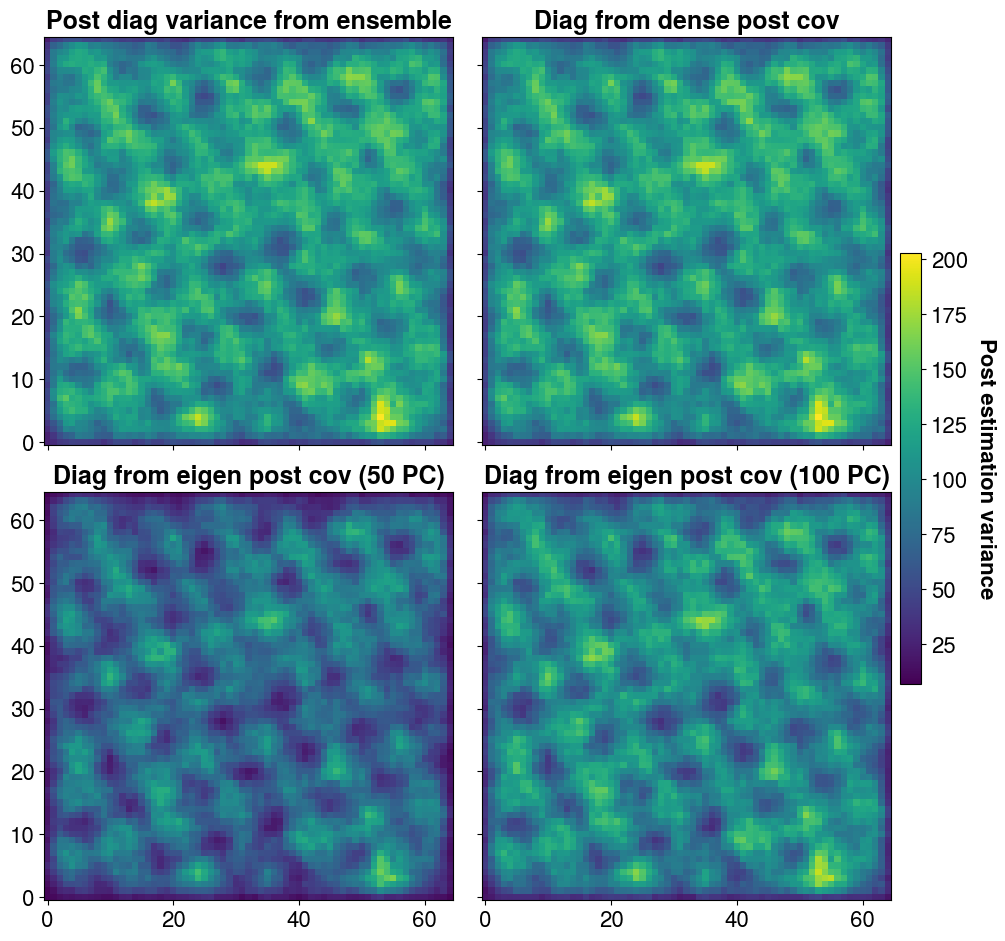

In [36]:
plotter = ngp.Plotter(
    plt.figure(figsize=(10.0, 9.3), constrained_layout=True),
    builder=ngp.SubplotsMosaicBuilder([["diag", "dense"], ["50pc", "100pc"]]),
)

ngp.multi_imshow(
    plotter.axes,
    data={
        "Post diag variance from ensemble": post_cov_ens.get_diagonal()
        .reshape(nx, ny, order="F")
        .T,
        "Diag from dense post cov": np.diagonal(post_cov_dense)
        .reshape(nx, ny, order="F")
        .T,
        "Diag from eigen post cov (50 PC)": post_cov_50_pc.get_diagonal()
        .reshape(nx, ny, order="F")
        .T,
        "Diag from eigen post cov (100 PC)": post_cov_100_pc.get_diagonal()
        .reshape(nx, ny, order="F")
        .T,
    },
    fig=plotter.fig,
    imshow_kwargs=dict(
        origin="lower",
        cmap=plt.get_cmap("viridis"),
        aspect="equal",
    ),
    cbar_kwargs=dict(pad=0.01, shrink=0.5),
    cbar_title="Post estimation variance",
)

With ESMDA, the final (posterior) ensemble already allows estimating the estimation variance on the searched parameters and on the predictions.

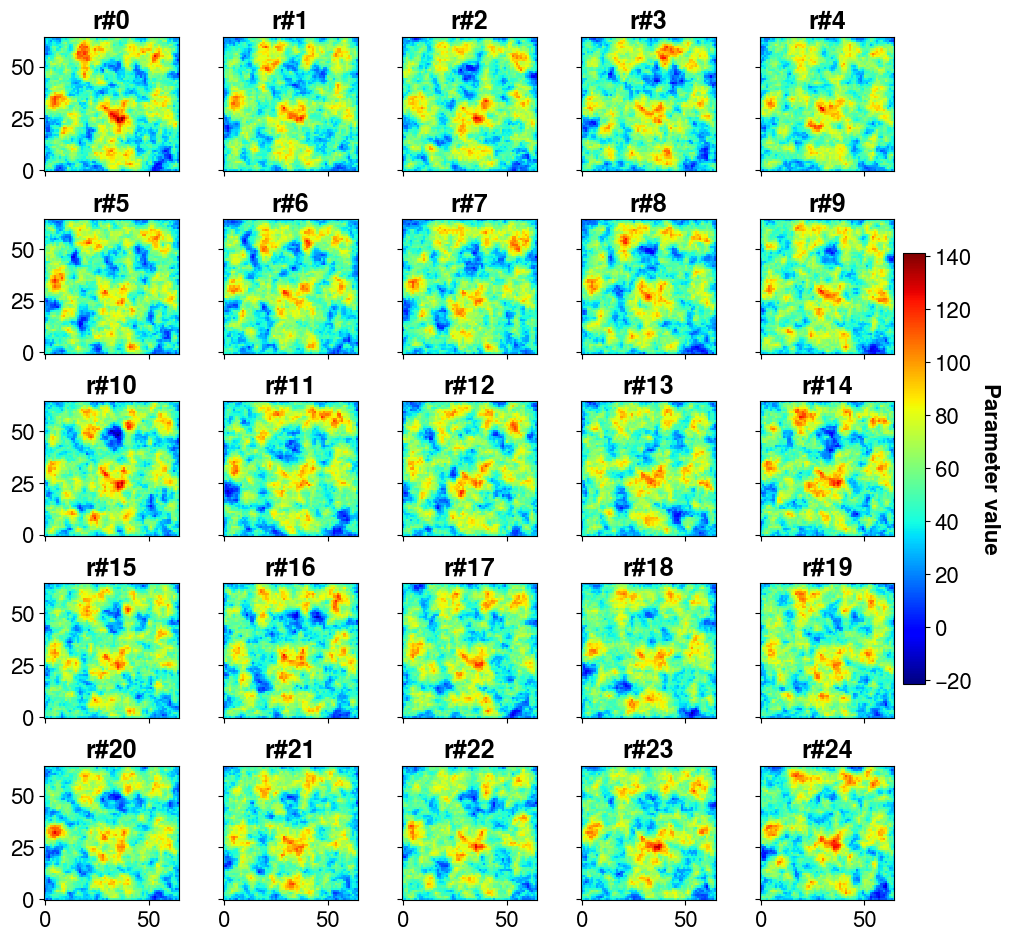

In [37]:
nrows = 5
ncols = 5
plotter = ngp.Plotter(
    plt.figure(figsize=(10.0, 9.3), constrained_layout=True),
    builder=ngp.SubplotsMosaicBuilder(
        [[f"ax{i}-{j}" for i in range(nrows)] for j in range(ncols)],
        sharex=True,
        sharey=True,
    ),
)

ngp.multi_imshow(
    plotter.axes,
    data={
        f"r#{i}": solver.m_prior[:, i].reshape(nx, ny, order="F").T
        for i in range(nrows * ncols)
    },
    fig=plotter.fig,
    imshow_kwargs=dict(
        origin="lower",
        cmap=plt.get_cmap("jet"),
        aspect="equal",
    ),
    cbar_kwargs=dict(pad=0.01, shrink=0.5),
    cbar_title="Parameter value",
)

But it should be noted that the interest of having the posterior covariance matrix (of inverted parameter values) is that it is possible to draw samples (realizations) from it and thus generate new ensembles to quantify the uncertainty on predictions (at the cost of one forward call per sample).

In [38]:
# make 200 posterior realizations => we sample from post_cov_ens
post_samples_200 = (
    solver.m_prior.mean(-1).T
    + post_cov_ens.sample_mvnormal(shape=(200,), random_state=solver.rng)
).T
post_samples_200.shape

(4225, 200)

- Let's plot the first 25 "new" realizations

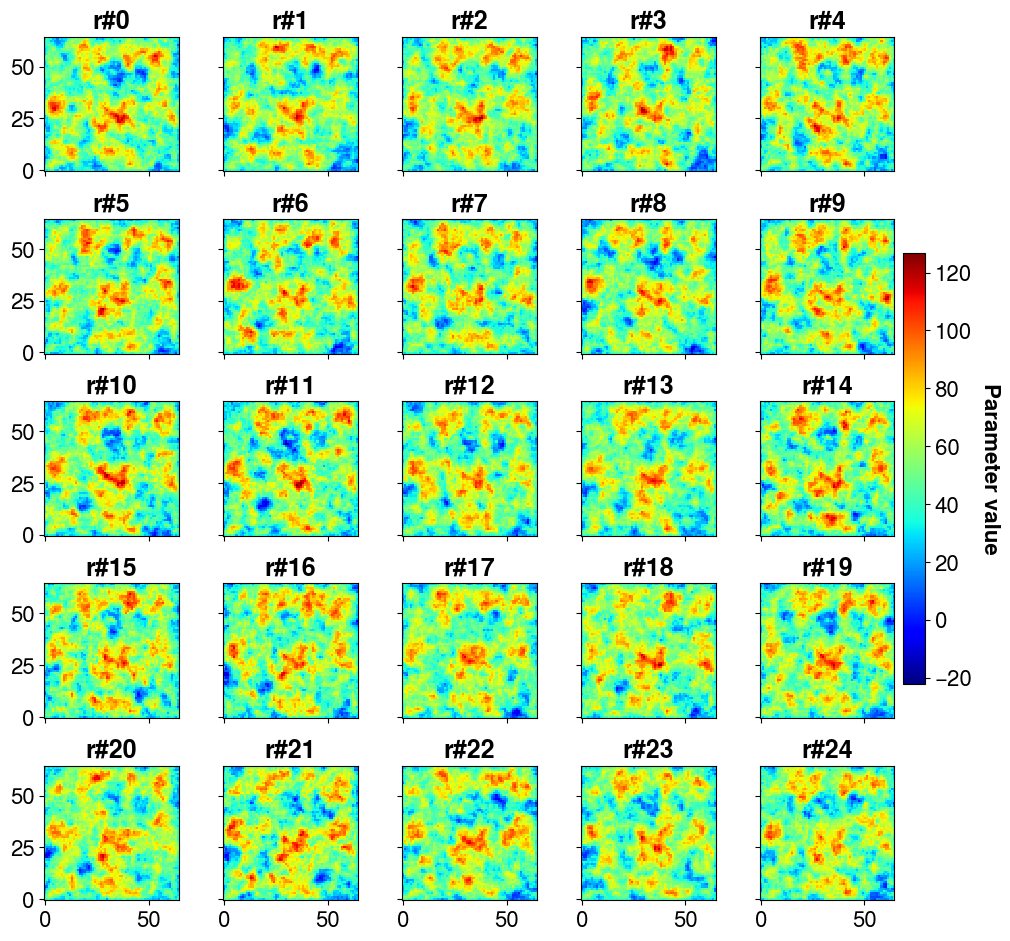

In [39]:
nrows = 5
ncols = 5
plotter = ngp.Plotter(
    plt.figure(figsize=(10.0, 9.3), constrained_layout=True),
    builder=ngp.SubplotsMosaicBuilder(
        [[f"ax{i}-{j}" for i in range(nrows)] for j in range(ncols)],
        sharex=True,
        sharey=True,
    ),
)

ngp.multi_imshow(
    plotter.axes,
    data={
        f"r#{i}": post_samples_200[:, i].reshape(nx, ny, order="F").T
        for i in range(nrows * ncols)
    },
    fig=plotter.fig,
    imshow_kwargs=dict(
        origin="lower",
        cmap=plt.get_cmap("jet"),
        aspect="equal",
    ),
    cbar_kwargs=dict(pad=0.01, shrink=0.5),
    cbar_title="Parameter value",
)

It is possible to find the variance back from the ensemble (or a sub ensemble). The more samples, the more accurate.

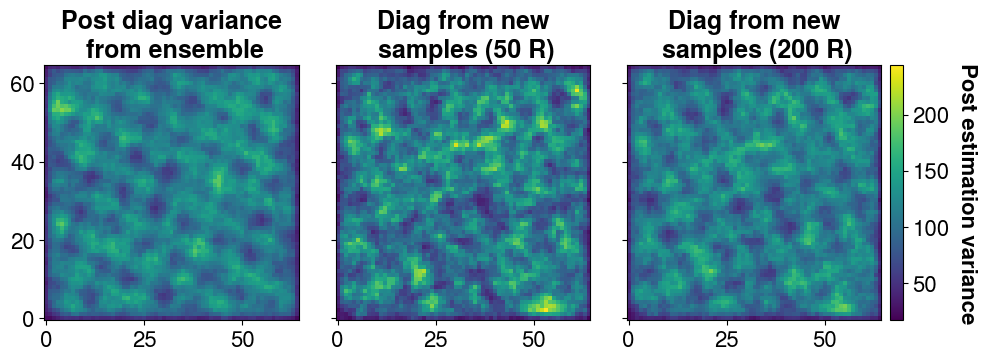

In [40]:
plotter = ngp.Plotter(
    plt.figure(figsize=(10.0, 3.5), constrained_layout=True),
    builder=ngp.SubplotsMosaicBuilder([["diag", "50pc", "ens"]]),
)

ngp.multi_imshow(
    plotter.axes,
    data={
        "Post diag variance\n from ensemble": post_cov_ens.get_diagonal().reshape(
            nx, ny, order="F"
        ),
        "Diag from new\n samples (50 R)": covmats.CovViaEnsemble(
            post_samples_200[:, :50].T
        )
        .get_diagonal()
        .reshape(nx, ny, order="F")
        .T,
        "Diag from new\n samples (200 R)": covmats.CovViaEnsemble(post_samples_200.T)
        .get_diagonal()
        .reshape(nx, ny, order="F")
        .T,
    },
    fig=plotter.fig,
    imshow_kwargs=dict(
        origin="lower",
        cmap=plt.get_cmap("viridis"),
        aspect="equal",
    ),
    cbar_kwargs=dict(pad=0.01),
    cbar_title="Post estimation variance",
)